# 1.&nbsp;Data Loading

In [1]:
import os
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/data/selected_columns.csv')

Mounted at /content/drive


# 2.&nbsp;Stratified Splitting

In [ ]:
import gc
from sklearn.model_selection import StratifiedKFold

# 1. Define features (X) and target (y)
X = df.drop(columns=['CVDINFR4'])
y = df['CVDINFR4']

# 2. Initialize StratifiedKFold with 10 splits
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 3. Create a list to store the folds (indices)
folds = list(skf.split(X, y))

# 4. For the first experimental run, we define:
train_val_idx, test_idx = folds[-1]

train_idx = train_val_idx[:-len(train_val_idx)//9]
val_idx = train_val_idx[-len(train_val_idx)//9:]

# 5. Create the actual dataframes
X_train, y_train = X.iloc[train_idx].copy(), y.iloc[train_idx]
X_val, y_val = X.iloc[val_idx].copy(), y.iloc[val_idx]
X_test, y_test = X.iloc[test_idx].copy(), y.iloc[test_idx]

# 6. Remove columns that are 100% NaN in X_train
sparse_cols = [col for col in X_train.columns if X_train[col].count() < 10]
print(f"Dropping {len(sparse_cols)} sparse columns: {sparse_cols}")
X_train.drop(columns=sparse_cols, inplace=True)
X_val.drop(columns=sparse_cols, inplace=True)
X_test.drop(columns=sparse_cols, inplace=True)

# 7. Delete original df to free RAM
del df
gc.collect()

# 8. Verification: Check if the target distribution is maintained
print(f"Train distribution: {y_train.mean()*100:.2f}%")
print(f"Val distribution:   {y_val.mean()*100:.2f}%")
print(f"Test distribution:  {y_test.mean()*100:.2f}%")
print("\nSplit completed successfully!")

Dropping 0 sparse columns: []
Train distribution: 5.46%
Val distribution:   5.32%
Test distribution:  5.44%

Split completed successfully!


# 3.&nbsp;Feature Engineering

In [3]:
def fast_feature_engineering(df_in):
  # Create a copy to avoid modifying the original dataframe
  df = df_in.copy()

  # Comorbidity Score
  chronic_cols = ['DIABETE4', 'ASTHMA3', 'CHCKDNY2', 'HAVARTH4', 'ADDEPEV3']
  df['CHRONIC_COUNT'] = (df[[c for c in chronic_cols if c in df.columns]] == 1).sum(axis=1)
  # BMI Group
  if '_BMI5' in df.columns:
    bmi = df['_BMI5'] / 100
    df['BMI_GROUP'] = pd.cut(bmi, bins=[0, 18.5, 25, 30, 100], labels=[1, 2, 3, 4]).astype(float)
  return df

X_train = fast_feature_engineering(X_train)
X_val = fast_feature_engineering(X_val)
X_test = fast_feature_engineering(X_test)

# 4.&nbsp;Selection (before Encoding)

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif

# Use a sample to find top features to save RAM
sample_size = 50000
X_sample = X_train.sample(n=min(sample_size, len(X_train)), random_state=42)
y_sample = y_train.loc[X_sample.index]

# Use simple fillna(0) for MI sample to prevent column dropping
# MI calculation only needs a numerical representation; simple fill is enough for selection
X_sample_filled = X_sample.fillna(0)

# Now mi_scores will ALWAYS match X_train.columns length
mi_scores = mutual_info_classif(X_sample_filled, y_sample, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train.columns)
selected_features = mi_series.sort_values(ascending=False).head(50).index.tolist()

X_train = X_train[selected_features]
X_val = X_val[selected_features]
X_test = X_test[selected_features]

# 5.&nbsp;Imputation & Encoding:

In [5]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Calculate cat_cols and num_cols
cat_cols = [col for col in X_train.columns if X_train[col].nunique() <= 10]
num_cols = [col for col in X_train.columns if col not in cat_cols]

# Numerical Imputation (Median)
num_imp = SimpleImputer(strategy='median')
X_train[num_cols] = num_imp.fit_transform(X_train[num_cols])
X_val[num_cols] = num_imp.transform(X_val[num_cols])
X_test[num_cols] = num_imp.transform(X_test[num_cols])

# Categorical Imputation (Most Frequent)
cat_imp = SimpleImputer(strategy='most_frequent')
X_train[cat_cols] = cat_imp.fit_transform(X_train[cat_cols])
X_val[cat_cols] = cat_imp.transform(X_val[cat_cols])
X_test[cat_cols] = cat_imp.transform(X_test[cat_cols])

# CATEGORICAL ENCODING (One-Hot Encoding)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
train_encoded = ohe.fit_transform(X_train[cat_cols])
val_encoded = ohe.transform(X_val[cat_cols])
test_encoded = ohe.transform(X_test[cat_cols])

encoded_cols = ohe.get_feature_names_out(cat_cols)

X_train_final = pd.concat([X_train[num_cols], pd.DataFrame(train_encoded, index=X_train.index, columns=encoded_cols)], axis=1)
X_val_final = pd.concat([X_val[num_cols], pd.DataFrame(val_encoded, index=X_val.index, columns=encoded_cols)], axis=1)
X_test_final = pd.concat([X_test[num_cols], pd.DataFrame(test_encoded, index=X_test.index, columns=encoded_cols)], axis=1)


# 6.&nbsp;Scaling:

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_val_scaled = scaler.transform(X_val_final)
X_test_scaled = scaler.transform(X_test_final)

print("\nPipeline completed successfully!")
print(f"Final shape: {X_train_scaled.shape}")


Pipeline completed successfully!
Final shape: (344604, 86)


# 7.&nbsp;Modeling:

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import numpy as np

# ---------------------------------------------------------
# 6.1. HANDLING IMBALANCE (The Algorithmic Way)
# ---------------------------------------------------------

# Model 1: Standard Random Forest with Class Weight
# Instead of SMOTE (which requires external lib), we use class_weight='balanced'
# This achieves a similar effect by penalizing mistakes on the minority class more heavily.
rf_standard = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Model 2: Balanced Random Forest
# 'balanced_subsample' calculates weights based on the bootstrap sample for every tree
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

# ---------------------------------------------------------
# 6.2. TRAINING
# ---------------------------------------------------------
print("Training Standard RF...")
rf_standard.fit(X_train_scaled, y_train)

print("Training Balanced RF...")
rf_balanced.fit(X_train_scaled, y_train)

# ---------------------------------------------------------
# 6.3. VALIDATION (On X_val_scaled)
# ---------------------------------------------------------
def evaluate_model(model, X, y, name):
    preds = model.predict(X)
    print(f"\n--- {name} Performance ---")
    print(classification_report(y, preds))
    print("Confusion Matrix:\n", confusion_matrix(y, preds))
    print(f"AUC-ROC: {roc_auc_score(y, model.predict_proba(X)[:, 1]):.4f}")

# Now run the evaluations again
evaluate_model(rf_standard, X_val_scaled, y_val, "Standard RF")
evaluate_model(rf_balanced, X_val_scaled, y_val, "Balanced RF")

Training Standard RF...
Training Balanced RF...

--- Standard RF Performance ---
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     40786
           1       0.65      1.00      0.79      2290

    accuracy                           0.97     43076
   macro avg       0.83      0.98      0.89     43076
weighted avg       0.98      0.97      0.97     43076

Confusion Matrix:
 [[39564  1222]
 [    9  2281]]
AUC-ROC: 0.9844

--- Balanced RF Performance ---
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     40786
           1       0.65      0.99      0.79      2290

    accuracy                           0.97     43076
   macro avg       0.83      0.98      0.89     43076
weighted avg       0.98      0.97      0.97     43076

Confusion Matrix:
 [[39564  1222]
 [   13  2277]]
AUC-ROC: 0.9845


# 8.&nbsp;Test:


=== FINAL MODEL COMPARISON ON TEST SET (P10) ===
             Accuracy    Recall  Precision  F1-Score   AUC-ROC    AUC-PR
Standard RF  0.971445  0.994883   0.656998  0.791384  0.985019  0.659642
Balanced RF  0.971306  0.992324   0.656417  0.790153  0.984914  0.655347


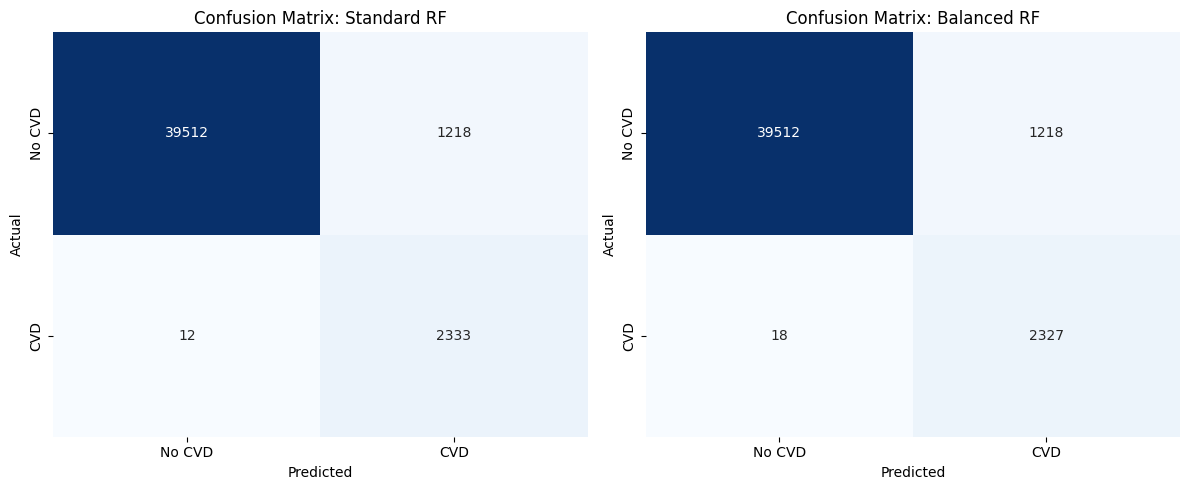

Saved: confusion_matrix_Standard_RF.png
Saved: confusion_matrix_Balanced_RF.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc, accuracy_score, precision_score, recall_score, f1_score

# ---------------------------------------------------------
# 1. GET PREDICTIONS FROM ALL MODELS
# ---------------------------------------------------------

# Standard RF
rf_std_probs = rf_standard.predict_proba(X_test_scaled)[:, 1]
rf_std_preds = rf_standard.predict(X_test_scaled)

# Balanced RF
rf_bal_probs = rf_balanced.predict_proba(X_test_scaled)[:, 1]
rf_bal_preds = rf_balanced.predict(X_test_scaled)

# ---------------------------------------------------------
# 2. EVALUATION FUNCTION (INCLUDING AUC-PR)
# ---------------------------------------------------------
def get_all_metrics(y_true, y_probs, y_preds):
    precision = precision_score(y_true, y_preds)
    recall = recall_score(y_true, y_preds)
    f1 = f1_score(y_true, y_preds)
    acc = accuracy_score(y_true, y_preds)
    roc_auc = roc_auc_score(y_true, y_probs)

    precision_pts, recall_pts, _ = precision_recall_curve(y_true, y_probs)
    auc_pr = auc(recall_pts, precision_pts)

    return [acc, recall, precision, f1, roc_auc, auc_pr]

# Calculate metrics
results = {
    "Standard RF": get_all_metrics(y_test, rf_std_probs, rf_std_preds),
    "Balanced RF": get_all_metrics(y_test, rf_bal_probs, rf_bal_preds),
}

# ---------------------------------------------------------
# 3. FINAL COMPARISON TABLE
# ---------------------------------------------------------
metrics_names = ['Accuracy', 'Recall', 'Precision', 'F1-Score', 'AUC-ROC', 'AUC-PR']
comparison_df = pd.DataFrame.from_dict(results, orient='index', columns=metrics_names)
print("\n=== FINAL MODEL COMPARISON ON TEST SET (P10) ===")
print(comparison_df)

# ---------------------------------------------------------
# 4. VISUALIZATION: CONFUSION MATRICES
# ---------------------------------------------------------
models_preds = [
    (rf_std_preds, "Standard RF"),
    (rf_bal_preds, "Balanced RF")
]

# --- PART A: Draw all matrices in one row for comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (preds, name) in enumerate(models_preds):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No CVD', 'CVD'], yticklabels=['No CVD', 'CVD'], ax=axes[i])
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.savefig("all_confusion_matrices.png", dpi=300)
plt.show()

# --- PART B: Save each matrix as a separate high-res file ---
for preds, name in models_preds:
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No CVD', 'CVD'], yticklabels=['No CVD', 'CVD'])
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    filename = f"confusion_matrix_{name.replace(' ', '_')}.png"
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.close()
    print(f"Saved: {filename}")